Initial Data Overview
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 367 entries, 0 to 366
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            367 non-null    object 
 1   Gender             356 non-null    object 
 2   Married            367 non-null    object 
 3   Dependents         357 non-null    object 
 4   Education          367 non-null    object 
 5   Self_Employed      344 non-null    object 
 6   ApplicantIncome    367 non-null    int64  
 7   CoapplicantIncome  367 non-null    int64  
 8   LoanAmount         362 non-null    float64
 9   Loan_Amount_Term   361 non-null    float64
 10  Credit_History     338 non-null    float64
 11  Property_Area      367 non-null    object 
dtypes: float64(3), int64(2), object(7)
memory usage: 34.5+ KB
None
Loan_ID               0
Gender               11
Married               0
Dependents           10
Education             0
Self_Employed

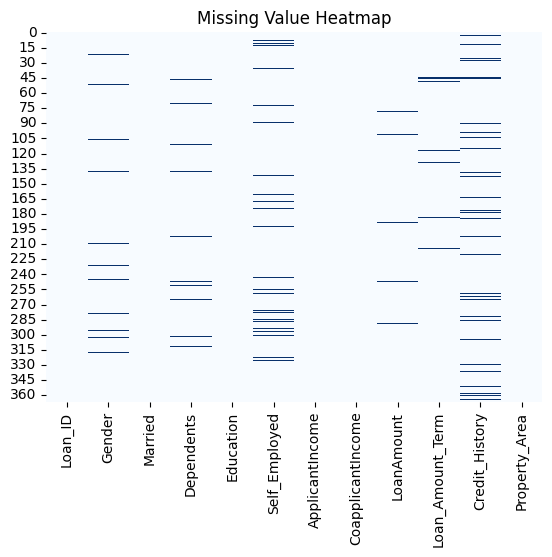

Initial Rows = 367
Final Rows = 367
Duplicates Removed = 0
Loan_ID               object
Gender                object
Married               object
Dependents            object
Education             object
Self_Employed         object
ApplicantIncome        int64
CoapplicantIncome      int64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area         object
dtype: object
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 367 entries, 0 to 366
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            367 non-null    object 
 1   Gender             367 non-null    object 
 2   Married            367 non-null    object 
 3   Dependents         367 non-null    object 
 4   Education          367 non-null    object 
 5   Self_Employed      367 non-null    object 
 6   ApplicantIncome    367 non-null    float64
 7   CoapplicantIncome  367 non-null    fl

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, StandardScaler

df = pd.read_csv("/content/test_Y3wMUE5_7gLdaTN.csv")

print("Initial Data Overview")
print(df.info())
print(df.isnull().sum())

sns.heatmap(df.isnull(), cbar=False, cmap="Blues")
plt.title("Missing Value Heatmap")
plt.show()

for col in ['Gender', 'Married', 'Dependents', 'Self_Employed']:
    df[col] = df[col].fillna(df[col].mode()[0])

df['LoanAmount'] = df['LoanAmount'].fillna(df['LoanAmount'].median())
df['Loan_Amount_Term'] = df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].mode()[0])
df['Credit_History'] = df['Credit_History'].fillna(df['Credit_History'].mode()[0])

initial_rows = df.shape[0]
df.drop_duplicates(inplace=True)

print("Initial Rows =", initial_rows)
print("Final Rows =", df.shape[0])
print("Duplicates Removed =", initial_rows - df.shape[0])

print(df.dtypes)

for col in ['Gender', 'Married', 'Education', 'Self_Employed', 'Property_Area']:
    df[col] = df[col].str.strip().str.capitalize()

min_max_scaler = MinMaxScaler()

scale_cols = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount']
df[scale_cols] = min_max_scaler.fit_transform(df[scale_cols])

scaler = StandardScaler()
df[['Credit_History']] = scaler.fit_transform(df[['Credit_History']])

print(df.info())
print(df.head())